In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/naghamalshbrawi/daresv2/Annotated_Paper_Dataset.csv
/kaggle/input/datasets/naghamalshbrawi/refined-bayyin-dataset/Refined_Bayyin_Dataset.csv
/kaggle/input/datasets/naghamalshbrawi/ebooks/merged_dataset.csv


In [3]:
!pip -q install pandas numpy scikit-learn

import re
import math
import numpy as np
import pandas as pd
from collections import Counter, defaultdict

# ---- CHANGE THIS ----
TEXT_COL = "D3Tok"   # or "Word" / "Lex" / "D3Lex"



In [4]:
!pip -q install transformers datasets accelerate evaluate scikit-learn

import os
import numpy as np
import pandas as pd
import torch

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from sklearn.model_selection import train_test_split

In [5]:
# ---- CHANGE THIS ----
CSV_PATH = "/kaggle/input/datasets/naghamalshbrawi/refined-bayyin-dataset/Refined_Bayyin_Dataset.csv"  # <-- update
TEXT_COL = "D3Tok"   # or "Word" or "Lex" or "D3Lex" depending on what you want
LABEL_COL = "Readability_Level"  # <-- update if yours is different (e.g., "label" / "readability_level")

df = pd.read_csv(CSV_PATH)

# Keep only what we need + drop NaNs
df = df[[TEXT_COL, LABEL_COL]].dropna().reset_index(drop=True)

# Ensure labels are int
df[LABEL_COL] = df[LABEL_COL].astype(int)

df.head()

,D3Tok,Readability_Level
0,من ال+ أدوات التي يستعمل +ها ال+ نجار في أعمال...,3
1,أربعة سباحين في ال+ محيط ال+ أزرق ال+ بلوري مع...,1
2,"نعم , أنا لا أستطيع أن أصدق نحن نتحدث عن ذلك .",2
3,تفضل يا سيد +ي . .,2
4,ك+ قول ال+ مثقب ال+ عبدي في قصيدة +ه :,4


In [6]:
# Convert 1..6 to 0..5
df["labels"] = df[LABEL_COL] - 1

# Sanity check
print(df["labels"].min(), df["labels"].max())
print(df["labels"].value_counts().sort_index())

0 5
labels
0    7735
1    7735
2    6689
3    7316
4    7707
5    7735
Name: count, dtype: int64


In [7]:
from sklearn.model_selection import train_test_split

SEED = 42  # same role as seed

# 80/20 split
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED,
    stratify=df["labels"]
)

# split the 80% train into 70% train + 10% val (since 0.125 * 0.80 = 0.10 total)
train_df, dev_df = train_test_split(
    train_df,
    test_size=0.125,
    random_state=SEED,
    stratify=train_df["labels"]
)

# Make a "splits" container like the datasets example
splits = {
    "train": train_df,
    "test": test_df,
    "validation": dev_df,   # dev == validation
}

print(f"Train: {len(splits['train'])}, Test: {len(splits['test'])}, Val: {len(splits['validation'])}")


Train: 31441, Test: 8984, Val: 4492


In [8]:
ds = DatasetDict({
    "train": Dataset.from_pandas(train_df.reset_index(drop=True)),
    "validation": Dataset.from_pandas(dev_df.reset_index(drop=True)),
    "test": Dataset.from_pandas(test_df.reset_index(drop=True)),
})
ds

DatasetDict({
    train: Dataset({
        features: ['D3Tok', 'Readability_Level', 'labels'],
        num_rows: 31441
    })
    validation: Dataset({
        features: ['D3Tok', 'Readability_Level', 'labels'],
        num_rows: 4492
    })
    test: Dataset({
        features: ['D3Tok', 'Readability_Level', 'labels'],
        num_rows: 8984
    })
})

In [9]:
MODEL_NAME = "aubmindlab/bert-base-arabertv2"
MAX_LEN = 128  # for sentence-level; you can use 256 if needed

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(batch):
    return tokenizer(
        batch[TEXT_COL],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN,
    )

ds_tok = ds.map(tokenize_batch, batched=True)
ds_tok = ds_tok.remove_columns([TEXT_COL, LABEL_COL])  # keep features only
ds_tok.set_format("torch")
ds_tok

Map:   0%|          | 0/31441 [00:00<?, ? examples/s]

Map:   0%|          | 0/4492 [00:00<?, ? examples/s]

Map:   0%|          | 0/8984 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 31441
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4492
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 8984
    })
})

In [10]:
num_labels = 6
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider

Epoch,Training Loss,Validation Loss,F1 Weighted,F1 Macro,Qwk
1,0.710259,0.625098,0.779013,0.776999,0.867906
2,0.496827,0.573802,0.796895,0.795138,0.880256
3,0.318642,0.656844,0.785006,0.783122,0.878224
4,0.196633,0.721358,0.793087,0.791352,0.887956
5,0.109025,0.822346,0.798947,0.797379,0.887033
6,0.064613,0.900547,0.798669,0.797130,0.884963


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Final Validation QWK: 0.8871342513445174
Confusion Matrix:
 [[648  55  24  46   0   0]
 [ 76 607  42  42   3   3]
 [ 59  56 507  35  10   2]
 [ 87 102  45 462  27   9]
 [  0   8  16  19 686  42]
 [  2   3   2  32  53 682]]


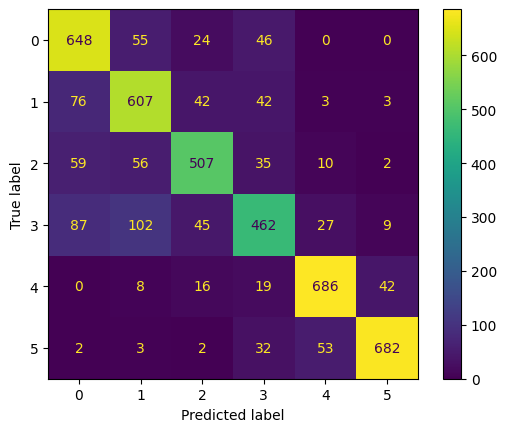

In [11]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, cohen_kappa_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    # sometimes logits come as a tuple (e.g., (logits,))
    if isinstance(logits, (tuple, list)):
        logits = logits[0]

    preds = np.argmax(logits, axis=-1)

    return {
        "f1_weighted": f1_score(labels, preds, average="weighted"),
        "f1_macro":    f1_score(labels, preds, average="macro"),
        "qwk":         cohen_kappa_score(labels, preds, weights="quadratic"),
    }

batch = 64
args = TrainingArguments(
    output_dir="/kaggle/working/arabertv2_bayyin",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=200,
    learning_rate=5e-5,
    per_device_train_batch_size=batch,
    per_device_eval_batch_size=batch,
    num_train_epochs=6,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=ds_tok["train"],
    eval_dataset=ds_tok["validation"],
    compute_metrics=compute_metrics,
)

trainer.train()

# ---------- Confusion Matrix on Validation ----------
pred_out = trainer.predict(ds_tok["validation"])

logits = pred_out.predictions
if isinstance(logits, (tuple, list)):
    logits = logits[0]

y_true = pred_out.label_ids
y_pred = np.argmax(logits, axis=-1)

# Print QWK (again, final) + show confusion matrix
qwk_final = cohen_kappa_score(y_true, y_pred, weights="quadratic")
print("Final Validation QWK:", qwk_final)

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.show()

In [12]:
SAVE_DIR = "/kaggle/working/arabertv2_bayyin_best"
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print("Saved to:", SAVE_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: /kaggle/working/arabertv2_bayyin_best


In [13]:
import shutil

# Zip the saved model directory
shutil.make_archive("/kaggle/working/arabertv2_bayyin_best", 'zip', "/kaggle/working/arabertv2_bayyin_best")

# Download the zip file
from IPython.display import FileLink
FileLink('/kaggle/working/arabertv2_bayyin_best.zip')

/kaggle/working/arabertv2_bayyin_best.zip

# Get soft labels p = softmax(logits) for train/dev/test

In [14]:
def get_soft_labels(trainer: Trainer, dataset_split) -> np.ndarray:
    """
    Returns soft labels (probabilities) shape: [N, num_labels]
    """
    preds = trainer.predict(dataset_split)
    logits = preds.predictions  # shape [N, num_labels]
    probs = torch.softmax(torch.tensor(logits), dim=-1).cpu().numpy()
    return probs

soft_train = get_soft_labels(trainer, ds_tok["train"])
soft_dev   = get_soft_labels(trainer, ds_tok["validation"])
soft_test  = get_soft_labels(trainer, ds_tok["test"])

print(soft_train.shape, soft_dev.shape, soft_test.shape)
print("Example probs:", soft_train[0], "sum =", soft_train[0].sum())

(31441, 6) (4492, 6) (8984, 6)
Example probs: [2.2484087e-04 1.0394985e-04 1.2748645e-04 8.8739529e-05 1.5834987e-04
 9.9929667e-01] sum = 1.0


In [15]:
def save_soft_labels_csv(original_df: pd.DataFrame, probs: np.ndarray, out_path: str):
    out = original_df.copy()
    for i in range(probs.shape[1]):
        out[f"prob_{i}"] = probs[:, i]
    out.to_csv(out_path, index=False)
    print("Saved:", out_path)

save_soft_labels_csv(train_df, soft_train, "/kaggle/working/train_with_softlabels.csv")
save_soft_labels_csv(dev_df,   soft_dev,   "/kaggle/working/dev_with_softlabels.csv")
save_soft_labels_csv(test_df,  soft_test,  "/kaggle/working/test_with_softlabels.csv")

Saved: /kaggle/working/train_with_softlabels.csv
Saved: /kaggle/working/dev_with_softlabels.csv
Saved: /kaggle/working/test_with_softlabels.csv


In [17]:
import shutil

files = [
    "/kaggle/working/train_with_softlabels.csv",
    "/kaggle/working/dev_with_softlabels.csv",
    "/kaggle/working/test_with_softlabels.csv",
]

# Zip all three into one archive
shutil.make_archive("/kaggle/working/softlabels", 'zip', "/kaggle/working", 
                    base_dir=None)

# Or download individually
from IPython.display import FileLink, display
for f in files:
    display(FileLink(f))

print("Also available in the Output panel on the right sidebar.")

/kaggle/working/train_with_softlabels.csv

/kaggle/working/dev_with_softlabels.csv

/kaggle/working/test_with_softlabels.csv

Also available in the Output panel on the right sidebar.


In [18]:
import os, zipfile
from IPython.display import FileLink, display

files = [
    "/kaggle/working/train_with_softlabels.csv",
    "/kaggle/working/dev_with_softlabels.csv",
    "/kaggle/working/test_with_softlabels.csv",
]

# تأكد أنها موجودة
for f in files:
    print(f, "->", os.path.exists(f))

zip_path = "/kaggle/working/softlabels.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for f in files:
        if os.path.exists(f):
            z.write(f, arcname=os.path.basename(f))

print("Created:", zip_path)
display(FileLink(zip_path))

/kaggle/working/train_with_softlabels.csv -> True
/kaggle/working/dev_with_softlabels.csv -> True
/kaggle/working/test_with_softlabels.csv -> True
Created: /kaggle/working/softlabels.zip


/kaggle/working/softlabels.zip

In [19]:
!ls /kaggle/working

arabertv2_bayyin	   dev_with_softlabels.csv   train_with_softlabels.csv
arabertv2_bayyin_best	   softlabels.zip
arabertv2_bayyin_best.zip  test_with_softlabels.csv


# ************Counting the Handcrafted Fetures************

 Lexico-Semantic Features (LxSem)

In [28]:
!pip -q install pandas numpy scikit-learn

import re
import math
import numpy as np
import pandas as pd
from collections import Counter, defaultdict

# ---- CHANGE THIS ----
TEXT_COL = "D3Tok"   # or "Word" / "Lex" / "D3Lex"

# Basic Arabic tokenization (keeps Arabic letters + clitic markers like '+' if D3Tok)
AR_TOKEN_RE = re.compile(r"[اأإآء-ي]+(?:\+[اأإآء-ي]+)*|[اأإآء-ي]+")

def tokenize_ar(text: str):
    if not isinstance(text, str):
        return []
    return AR_TOKEN_RE.findall(text)

def safe_div(a, b):
    return a / b if b != 0 else 0.0

a- TTRF (Type-Token Ratio Features)

In [29]:
def mtld(tokens, ttr_threshold=0.72):
    """
    MTLD (Measure of Textual Lexical Diversity).
    Works better on longer texts, but we compute it anyway for consistency.
    """
    if not tokens:
        return 0.0

    factors = 0
    types = set()
    token_count = 0

    for tok in tokens:
        token_count += 1
        types.add(tok)
        ttr = len(types) / token_count
        if ttr <= ttr_threshold:
            factors += 1
            types = set()
            token_count = 0

    # partial factor
    if token_count > 0:
        ttr = len(types) / token_count
        if ttr != 1:
            factors += (1 - ttr) / (1 - ttr_threshold)

    return safe_div(len(tokens), factors) if factors > 0 else float(len(tokens))

def compute_ttrf_for_text(text):
    toks = tokenize_ar(text)
    total = len(toks)
    unique = len(set(toks))

    simp_ttr = safe_div(unique, total)
    corr_ttr = safe_div(unique, math.sqrt(2 * total))               # unique / sqrt(2*total)
    bilo_ttr = safe_div(math.log(unique + 1e-12), math.log(total + 1e-12)) if total > 1 and unique > 1 else 0.0
    uber_ttr = safe_div((math.log(unique + 1e-12) ** 2), math.log(safe_div(total, unique) + 1e-12)) if total > 1 and unique > 1 else 0.0
    mtld_val = mtld(toks, ttr_threshold=0.72)

    return {
        "SimpTTR_S": simp_ttr,
        "CorrTTR_S": corr_ttr,
        "BiLoTTR_S": bilo_ttr,
        "UberTTR_S": uber_ttr,
        "MTLDTTR_S": mtld_val
    }

ttrf_df = df[TEXT_COL].apply(compute_ttrf_for_text).apply(pd.Series)
ttrf_df.head()

,SimpTTR_S,CorrTTR_S,BiLoTTR_S,UberTTR_S,MTLDTTR_S
0,0.733333,2.840188,0.908810,3.080571e+01,30.00
1,0.846154,2.157277,0.934870,3.441940e+01,23.66
2,1.000000,2.236068,1.000000,5.301427e+12,10.00
3,1.000000,1.414214,1.000000,1.921641e+12,4.00
4,0.888889,1.885618,0.946395,3.671222e+01,22.68


b-VarF (Variation Ratio Features)

In [66]:
# --- Setup: POS pipeline (EGY) ---
!pip -q install -U transformers accelerate sentencepiece

import torch, re, math
import pandas as pd
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline

MODEL_ID = "CAMeL-Lab/bert-base-arabic-camelbert-ca-pos-egy"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForTokenClassification.from_pretrained(MODEL_ID)

pos_pipe = pipeline(
    "token-classification",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="simple",
    device=0 if torch.cuda.is_available() else -1
)

# Basic Arabic tokenization (fallback for your other features if needed)
AR_TOKEN_RE = re.compile(r"[اأإآء-ي]+(?:\+[اأإآء-ي]+)*|[اأإآء-ي]+")

def tokenize_ar(text: str):
    if not isinstance(text, str):
        return []
    return AR_TOKEN_RE.findall(text)

def safe_div(a, b):
    return 0.0 if b == 0 else a / b

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: CAMeL-Lab/bert-base-arabic-camelbert-ca-pos-egy
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.pooler.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
bert.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [67]:
# --- Coarse POS mapping for HF labels ---
# HF model labels are like: "NOUN", "VERB", "ADJ", "ADV", etc (may vary slightly).
# We map them to your buckets.
POS_MAP_HF = {
    "noun": {"noun", "propn"},   # sometimes models use PROPN
    "verb": {"verb"},
    "adj":  {"adj"},
    "adv":  {"adv"},
}

def coarse_pos_hf(label: str):
    if label is None:
        return None
    t = label.lower()
    # exact match
    for k, vals in POS_MAP_HF.items():
        if t in vals:
            return k
    # prefix / contains fallback
    if "noun" in t or "propn" in t: return "noun"
    if "verb" in t: return "verb"
    if "adj"  in t: return "adj"
    if "adv"  in t: return "adv"
    return None

# --- POS tagging using HF pipeline (replaces mle.disambiguate) ---
def pos_tag_text_hf(text: str):
    """
    Returns list of coarse POS tags aligned to pipeline 'word' spans (not your regex tokens).
    We'll use the pipeline words to build buckets, which is enough for variation metrics.
    """
    if not isinstance(text, str) or not text.strip():
        return [], []
    preds = pos_pipe(text)
    words = [p["word"] for p in preds]
    tags  = [coarse_pos_hf(p.get("entity_group")) for p in preds]
    return words, tags

# --- Your variation metrics (works on bucket token lists) ---
def variation_metrics(tokens_of_pos):
    total = len(tokens_of_pos)
    unique = len(set(tokens_of_pos))
    simp = safe_div(unique, total)
    squa = safe_div((unique ** 2), total)
    corr = safe_div(unique, math.sqrt(2 * total))
    return simp, squa, corr

def compute_varf_hf(text: str):
    words, tags = pos_tag_text_hf(text)

    buckets = {"noun": [], "verb": [], "adj": [], "adv": []}
    for w, t in zip(words, tags):
        if t in buckets and isinstance(w, str) and w.strip():
            buckets[t].append(w)

    out = {}
    # Nouns
    simp, squa, corr = variation_metrics(buckets["noun"])
    out["SimpNoV_S"] = simp
    out["SquaNoV_S"] = squa
    out["CorrNoV_S"] = corr
    # Verbs
    simp, squa, corr = variation_metrics(buckets["verb"])
    out["SimpVeV_S"] = simp
    out["SquaVeV_S"] = squa
    out["CorrVeV_S"] = corr
    # Adjectives
    simp, squa, corr = variation_metrics(buckets["adj"])
    out["SimpAjV_S"] = simp
    out["SquaAjV_S"] = squa
    out["CorrAjV_S"] = corr
    # Adverbs
    simp, squa, corr = variation_metrics(buckets["adv"])
    out["SimpAvV_S"] = simp
    out["SquaAvV_S"] = squa
    out["CorrAvV_S"] = corr

    return out

In [68]:
# Apply to your dataframe column 
# TEXT_COL should be "Word" (recommended). If it's D3Tok, POS quality may drop.
df = pd.read_csv(CSV_PATH)
varf_df = df["Word"].apply(compute_varf_hf).apply(pd.Series)
varf_df.head()

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,SimpNoV_S,SquaNoV_S,CorrNoV_S,SimpVeV_S,SquaVeV_S,CorrVeV_S,SimpAjV_S,SquaAjV_S,CorrAjV_S,SimpAvV_S,SquaAvV_S,CorrAvV_S
0,1.0,7.0,1.870829,1.0,2.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,4.0,1.414214,1.0,1.0,0.707107,1.0,2.0,1.0,0.0,0.0,0.0
2,0.0,0.0,0.000000,1.0,3.0,1.224745,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,1.0,0.707107,1.0,1.0,0.707107,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,3.0,1.224745,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


c- WorF (Word Familiarity Features)

c 1 - Build frequency lexicon from a reference corpus

In [82]:
# Cell 1: imports + tokenizer 
import re
import numpy as np
import pandas as pd
from collections import Counter
from datasets import load_dataset

# ---- CHANGE THIS for YOUR Bayyin DF ----
TEXT_COL = "Word"   # or "Word" / "Lex" / "D3Lex"

AR_TOKEN_RE = re.compile(r"[اأإآء-ي]+(?:\+[اأإآء-ي]+)*|[اأإآء-ي]+")

def tokenize_ar(text: str):
    if not isinstance(text, str):
        return []
    return AR_TOKEN_RE.findall(text)

In [83]:
def guess_text_column(df: pd.DataFrame, preferred=None):
    """
    Tries to guess the column containing Arabic text.
    If preferred is provided and exists, returns it.
    """
    if preferred and preferred in df.columns:
        return preferred
    
    candidates = ["text", "Sentence","ar", "arabic", "arabic_text","Word" ]
    for c in candidates:
        if c in df.columns:
            return c
    
    # fallback: choose object column with highest avg token count
    obj_cols = [c for c in df.columns if df[c].dtype == "object"]
    if not obj_cols:
        return None
    
    best_col, best_score = None, -1
    for c in obj_cols:
        sample = df[c].dropna().astype(str).head(200).tolist()
        if not sample:
            continue
        avg_len = np.mean([len(tokenize_ar(s)) for s in sample])
        if avg_len > best_score:
            best_score = avg_len
            best_col = c
    return best_col

In [84]:
# Cell 3: Load BAREC (HuggingFace) + convert to pandas
ds_barec = load_dataset("CAMeL-Lab/BAREC-Shared-Task-2025-sent")

# choose a split that exists
split_name = "train" if "train" in ds_barec else list(ds_barec.keys())[0]
barec_df = ds_barec[split_name].to_pandas()

barec_text_col = guess_text_column(barec_df)
print("BAREC split:", split_name)
print("BAREC columns:", list(barec_df.columns))
print("BAREC guessed text col:", barec_text_col)

# quick peek
barec_df[[barec_text_col]].head()

BAREC split: train
BAREC columns: ['ID', 'Sentence', 'Word_Count', 'Readability_Level', 'Readability_Level_19', 'Readability_Level_7', 'Readability_Level_5', 'Readability_Level_3', 'Annotator', 'Document', 'Source', 'Book', 'Author', 'Domain', 'Text_Class']
BAREC guessed text col: Sentence


,Sentence
0,مجلة كل الأولاد وكل البنات
1,ماجد
2,الأربعاء 21 يناير 1987
3,الموافق 21 جمادى الأول 1407هــ
4,السنة الثامنة


In [85]:
# Cell 4: Load DARES CSV (after you download it) + Ebooks CSV
# --- CHANGE PATHS ---
DARES_PATH = "/kaggle/input/datasets/naghamalshbrawi/daresv2/Annotated_Paper_Dataset.csv"  
EBOOK_PATH = "/kaggle/input/datasets/naghamalshbrawi/ebooks/merged_dataset.csv"                   

dares_df = pd.read_csv(DARES_PATH)
ebook_df = pd.read_csv(EBOOK_PATH)

dares_text_col = guess_text_column(dares_df)
ebook_text_col = guess_text_column(ebook_df)

print("DARES columns:", list(dares_df.columns))
print("DARES guessed text col:", dares_text_col)

print("\nEBOOK columns:", list(ebook_df.columns))
print("EBOOK guessed text col:", ebook_text_col)

DARES columns: ['ID', 'Word', 'Len', 'Fine-grained', 'Coarse-grained', 'Filename', 'Text', 'Sent_Num', 'Sent_Len', 'English_Filename', 'Arabic_Filename', 'Annot1', 'Annot2', 'Annot3']
DARES guessed text col: Word

EBOOK columns: ['booknr', 'category', 'title', 'author', 'pubdate', 'origtitle', 'origauthor', 'wc', 'origpubdate', 'origlang.ar', 'transdate', 'translation', 'origlang', 'origpubdate.full', 'transdate.full', 'category.main', 'text']
EBOOK guessed text col: text


In [86]:
# Cell 5: Build the reference corpus tokens (BAREC + DARES + Ebooks)
def collect_tokens_from_df(df: pd.DataFrame, text_col: str):
    toks = []
    for txt in df[text_col].astype(str).tolist():
        toks.extend(tokenize_ar(txt))
    return toks

ref_tokens = []
ref_tokens.extend(collect_tokens_from_df(barec_df, barec_text_col))
ref_tokens.extend(collect_tokens_from_df(dares_df, dares_text_col))
ref_tokens.extend(collect_tokens_from_df(ebook_df, ebook_text_col))

freq = Counter(ref_tokens)
N = sum(freq.values())

print("Reference corpus total tokens N:", N)
print("Unique tokens:", len(freq))
print("Top 10 tokens:", freq.most_common(10))

Reference corpus total tokens N: 74704525
Unique tokens: 1042119
Top 10 tokens: [('ا', 1980352), ('في', 1971726), ('من', 1688444), ('أن', 924669), ('على', 915052), ('إلى', 754873), ('م', 672754), ('ي', 642941), ('ل', 511882), ('ما', 499256)]


In [87]:
# Cell 6: Frequency-based features (log freq + rare ratio)
LOW_THR = 15

def compute_frequency_features(text: str):
    tokens = tokenize_ar(str(text))
    if len(tokens) == 0:
        return {
            "mean_log_freq": 0.0,
            "min_log_freq": 0.0,
            "rare_ratio": 0.0
        }
    
    log_freqs = []
    rare_count = 0
    
    for tok in tokens:
        f = freq.get(tok, 0)            # count in reference corpus
        log_f = np.log(f + 1)           # log frequency
        log_freqs.append(log_f)
        if f <= LOW_THR:
            rare_count += 1
    
    return {
        "mean_log_freq": float(np.mean(log_freqs)),
        "min_log_freq": float(np.min(log_freqs)),
        "rare_ratio": float(rare_count / len(tokens))
    }

In [88]:
# Cell 7: Apply features to Bayyin df (YOUR df)
df = pd.read_csv("/kaggle/input/datasets/naghamalshbrawi/refined-bayyin-dataset/Refined_Bayyin_Dataset.csv")  

# Ensure TEXT_COL exists
assert TEXT_COL in df.columns, f"{TEXT_COL} not found in df columns: {df.columns}"

features_series = df[TEXT_COL].apply(compute_frequency_features)
features_df = pd.DataFrame(list(features_series))

df = pd.concat([df, features_df], axis=1)

df[[TEXT_COL, "mean_log_freq", "min_log_freq", "rare_ratio"]].head()

,Word,mean_log_freq,min_log_freq,rare_ratio
0,من الأدوات التي يستعملها النجار في أعماله . ( ...,9.245063,3.332205,0.0
1,أربعة سباحين في المحيط الأزرق البلوري مع ألواح...,7.044753,0.693147,0.2
2,"نعم , أنا لا أستطيع أن أصدق نحن نتحدث عن ذلك .",10.579524,6.870053,0.0
3,تفضل يا سيدي . .,9.493215,6.904751,0.0
4,كقول المثقب العبدي في قصيدته :,7.288993,3.332205,0.0


c 2 - Compute WorF-like columns (total + avg per sentence + avg per token + log10 + low-frequency totals)

In [89]:
def compute_worf(text):
    toks = tokenize_ar(text)
    if not toks:
        return {
            "to_FreqCount": 0, "as_FreqCount": 0.0, "at_FreqCount": 0.0,
            "to_LowCount": 0, "as_LowCount": 0.0, "at_LowCount": 0.0,
            "to_Lg10WF": 0.0, "as_Lg10WF": 0.0, "at_Lg10WF": 0.0
        }

    counts = [freq.get(t, 0) for t in toks]
    low_flags = [1 if c <= LOW_THR else 0 for c in counts]
    lg10 = [math.log10(c + 1) for c in counts]  # +1 to avoid log(0)

    to_freq = sum(counts)
    to_low = sum(low_flags)
    to_lg10 = sum(lg10)

    total_tokens = len(toks)

    # "per sentence" == per sample (since each row is one sentence)
    return {
        "to_FreqCount": to_freq,
        "as_FreqCount": float(to_freq),
        "at_FreqCount": safe_div(to_freq, total_tokens),

        "to_LowCount": to_low,
        "as_LowCount": float(to_low),
        "at_LowCount": safe_div(to_low, total_tokens),

        "to_Lg10WF": to_lg10,
        "as_Lg10WF": float(to_lg10),
        "at_Lg10WF": safe_div(to_lg10, total_tokens),
    }

worf_df = df[TEXT_COL].apply(compute_worf).apply(pd.Series)
worf_df.head()

,to_FreqCount,as_FreqCount,at_FreqCount,to_LowCount,as_LowCount,at_LowCount,to_Lg10WF,as_Lg10WF,at_Lg10WF
0,5586787.0,5586787.0,266037.476190,0.0,0.0,0.0,84.316674,84.316674,4.015080
1,2110091.0,2110091.0,211009.100000,2.0,2.0,0.2,30.594972,30.594972,3.059497
2,2126233.0,2126233.0,212623.300000,0.0,0.0,0.0,45.946290,45.946290,4.594629
3,156755.0,156755.0,52251.666667,0.0,0.0,0.0,12.368552,12.368552,4.122851
4,1974036.0,1974036.0,394807.200000,0.0,0.0,0.0,15.827847,15.827847,3.165569


c3 - Grade-based word appearance (from DARES)

In [98]:
# ===== DARES (Fine-grained G1..G12) -> token avg grade -> apply to Bayyin Word =====
from collections import defaultdict
import numpy as np
import pandas as pd

# 1) Load DARES
dares_path = "/kaggle/input/datasets/naghamalshbrawi/daresv2/Annotated_Paper_Dataset.csv"
dares_df = pd.read_csv(dares_path)

dares_text_col = "Word"
grade_col = "Fine-grained"   # values: G1..G12

# 2) Clean + convert grade: "G10" -> 10
dares_df = dares_df[[dares_text_col, grade_col]].dropna()
dares_df["grade_num"] = (
    dares_df[grade_col].astype(str).str.strip()
    .str.replace("G", "", regex=False)
)

# keep only valid digits
dares_df = dares_df[dares_df["grade_num"].str.fullmatch(r"\d+")]
dares_df["grade_num"] = dares_df["grade_num"].astype(int)

print("DARES rows after cleaning:", len(dares_df))
print("DARES grades:", sorted(dares_df["grade_num"].unique().tolist())[:20], "...")

# 3) Build token -> average grade (using your tokenize_ar)
token_grade_sum = defaultdict(float)
token_grade_cnt = defaultdict(float)

for txt, gr in zip(dares_df[dares_text_col].astype(str), dares_df["grade_num"].tolist()):
    for t in tokenize_ar(txt):
        token_grade_sum[t] += gr
        token_grade_cnt[t] += 1

token_avg_grade = {t: token_grade_sum[t] / token_grade_cnt[t] for t in token_grade_cnt}
print("Unique tokens in token_avg_grade:", len(token_avg_grade))

# 4) Compute features for Bayyin (Word column)
def compute_grade_features(text):
    toks = tokenize_ar(text)
    grades = [token_avg_grade.get(t) for t in toks if t in token_avg_grade]
    if not grades:
        return {"avg_word_grade": np.nan, "max_word_grade": np.nan, "pct_grade10plus": 0.0}
    grades = np.asarray(grades, dtype=float)
    return {
        "avg_word_grade": float(grades.mean()),
        "max_word_grade": float(grades.max()),
        "pct_grade10plus": float((grades >= 10.0).mean())
    }

grade_df = df["Word"].astype(str).apply(compute_grade_features).apply(pd.Series)
grade_df.head()

DARES rows after cleaning: 13870
DARES grades: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] ...
Unique tokens in token_avg_grade: 9817


,avg_word_grade,max_word_grade,pct_grade10plus
0,6.0,10.0,0.25
1,6.5,10.0,0.50
2,NaN,NaN,0.00
3,NaN,NaN,0.00
4,11.0,11.0,1.00


In [99]:
grade_df["avg_word_grade"] = grade_df["avg_word_grade"].fillna(0.0)
grade_df["max_word_grade"] = grade_df["max_word_grade"].fillna(0.0)
# pct_grade10plus already 0.0 for OOV cases

c4 - Word concreteness proxies

In [114]:
# ---- Abstract suffix feature only ----

ABSTRACT_SUFFIXES = ("ية", "يات", "يون", "ات", "ة")

def compute_abstract_ratio(text):
    toks = tokenize_ar(text)
    if not toks:
        return 0.0
    
    abstract = sum(1 for t in toks if t.endswith(ABSTRACT_SUFFIXES))
    return abstract / len(toks)

# Apply to Bayyin Word column
abstract_df = df["Word"].astype(str).apply(compute_abstract_ratio).to_frame("abstract_suffix_ratio")

abstract_df.head()

,abstract_suffix_ratio
0,0.238095
1,0.100000
2,0.000000
3,0.000000
4,0.000000


In [115]:
tmp = pd.concat([df["Readability_Level"], conc_df], axis=1)
tmp.groupby("Readability_Level").mean()

,abstract_suffix_ratio,al_prefix_ratio,digit_ratio
Readability_Level,,,
1,0.033102,0.263114,0.003040
2,0.020682,0.170002,0.004208
3,0.020483,0.211594,0.002342
4,0.035662,0.214909,0.010275
5,0.062649,0.285123,0.004322
6,0.032553,0.211639,0.004821


c4 - Word length variance 

In [116]:
def compute_word_length_variance(text):
    toks = tokenize_ar(text)
    if not toks:
        return {"avg_word_len": 0.0, "var_word_len": 0.0, "std_word_len": 0.0}
    lens = np.array([len(t) for t in toks], dtype=float)
    return {
        "avg_word_len": float(lens.mean()),
        "var_word_len": float(lens.var(ddof=0)),
        "std_word_len": float(lens.std(ddof=0))
    }

lenvar_df = df[TEXT_COL].apply(compute_word_length_variance).apply(pd.Series)
lenvar_df.head()

,avg_word_len,var_word_len,std_word_len
0,4.095238,4.943311,2.223356
1,4.800000,2.560000,1.600000
2,3.300000,1.610000,1.268858
3,3.333333,0.888889,0.942809
4,4.800000,2.560000,1.600000


D- Morphological ambiguity count

In [117]:
!pip -q install -U camel-tools

import numpy as np
import pandas as pd
from camel_tools.morphology.database import MorphologyDB
from camel_tools.morphology.analyzer import Analyzer

# ✅ Load built-in CALIMA MSA morphology DB (no .pretrained())
db = MorphologyDB.builtin_db("calima-msa-r13")
analyzer = Analyzer(db)

def morph_ambiguity_features(text):
    toks = tokenize_ar(text)
    if not toks:
        return {"avg_morph_ambig": 0.0, "max_morph_ambig": 0.0}

    ambigs = []
    for t in toks:
        try:
            analyses = analyzer.analyze(t)
            ambigs.append(len(analyses))
        except Exception:
            ambigs.append(0)

    ambigs = np.asarray(ambigs, dtype=float)
    return {
        "avg_morph_ambig": float(ambigs.mean()),
        "max_morph_ambig": float(ambigs.max())
    }

# ✅ Apply on Word (recommended). If you insist on TEXT_COL, keep it.
ambig_df = df["Word"].astype(str).apply(morph_ambiguity_features).apply(pd.Series)
ambig_df.head()

,avg_morph_ambig,max_morph_ambig
0,10.619048,60.0
1,6.000000,13.0
2,8.100000,21.0
3,7.666667,16.0
4,2.800000,4.0


Concatinting Lexico-Semantic Features

In [118]:
features = pd.concat(
    [ttrf_df, varf_df, worf_df, grade_df, conc_df, lenvar_df, ambig_df],
    axis=1
)

features.head(), features.shape

(   SimpTTR_S  CorrTTR_S  BiLoTTR_S     UberTTR_S  MTLDTTR_S  SimpNoV_S  \
 0   0.733333   2.840188   0.908810  3.080571e+01      30.00        1.0   
 1   0.846154   2.157277   0.934870  3.441940e+01      23.66        1.0   
 2   1.000000   2.236068   1.000000  5.301427e+12      10.00        0.0   
 3   1.000000   1.414214   1.000000  1.921641e+12       4.00        1.0   
 4   0.888889   1.885618   0.946395  3.671222e+01      22.68        1.0   
 
    SquaNoV_S  CorrNoV_S  SimpVeV_S  SquaVeV_S  ...  max_word_grade  \
 0        7.0   1.870829        1.0        2.0  ...            10.0   
 1        4.0   1.414214        1.0        1.0  ...            10.0   
 2        0.0   0.000000        1.0        3.0  ...             0.0   
 3        1.0   0.707107        1.0        1.0  ...             0.0   
 4        3.0   1.224745        0.0        0.0  ...            11.0   
 
    pct_grade10plus  abstract_suffix_ratio  al_prefix_ratio  digit_ratio  \
 0             0.25               0.047619  

In [120]:
# Save as CSV
features.to_csv("bayyin_handcrafted_features.csv", index=False)

# or save as pickle (faster to reload, keeps dtypes better)
features.to_pickle("bayyin_handcrafted_features.pkl")

print("Saved ✅")

Saved ✅


Synta (Syntactic Features)

a - Phrasal Features (PhrF)

In [124]:
import numpy as np
import pandas as pd

# nlp = stanza.Pipeline("ar", processors="tokenize,pos,lemma,depparse", use_gpu=True)

def extract_dep_phrase_proxies(text: str):
    doc = nlp(text)
    words = [w for s in doc.sentences for w in s.words]
    if not words:
        return {
            "tok_n": 0,
            "to_NP_P": 0, "at_NP_P": 0.0,
            "to_VP_P": 0, "at_VP_P": 0.0,
            "to_PP_P": 0, "at_PP_P": 0.0,
            "to_ADJP_P": 0, "at_ADJP_P": 0.0,
            "to_ADVP_P": 0, "at_ADVP_P": 0.0,
            "to_SBAR_P": 0, "at_SBAR_P": 0.0,
            "ra_NoVeP_P": 0.0,
            "ra_VeSuP_P": 0.0,
        }

    tok_n = len(words)

    # POS-based proxies
    np_cnt   = sum(w.upos in ("NOUN", "PROPN", "PRON") for w in words)
    vp_cnt   = sum(w.upos in ("VERB", "AUX") for w in words)
    adjp_cnt = sum(w.upos == "ADJ" for w in words)
    advp_cnt = sum(w.upos == "ADV" for w in words)

    # PP proxy: adposition + case-marked nominals
    # (Arabic often uses ADP, and dependency relation "case" for prepositions)
    pp_cnt = sum(w.upos == "ADP" for w in words) + sum(w.deprel == "case" for w in words)

    # SBAR proxy: subordinate/clausal relations
    sbar_cnt = sum(w.deprel in ("acl", "advcl", "ccomp", "xcomp", "csubj") for w in words)

    feats = {
        "tok_n": tok_n,

        "to_NP_P": np_cnt,
        "at_NP_P": np_cnt / tok_n,

        "to_VP_P": vp_cnt,
        "at_VP_P": vp_cnt / tok_n,

        "to_PP_P": pp_cnt,
        "at_PP_P": pp_cnt / tok_n,

        "to_ADJP_P": adjp_cnt,
        "at_ADJP_P": adjp_cnt / tok_n,

        "to_ADVP_P": advp_cnt,
        "at_ADVP_P": advp_cnt / tok_n,

        "to_SBAR_P": sbar_cnt,
        "at_SBAR_P": sbar_cnt / tok_n,

        # ratios similar to yours
        "ra_NoVeP_P": (np_cnt / vp_cnt) if vp_cnt else 0.0,
        "ra_VeSuP_P": (vp_cnt / sbar_cnt) if sbar_cnt else 0.0,
    }
    return feats

phrf_df = df["Word"].astype(str).apply(extract_dep_phrase_proxies).apply(pd.Series)
phrf_df.head()

,tok_n,to_NP_P,at_NP_P,to_VP_P,at_VP_P,to_PP_P,at_PP_P,to_ADJP_P,at_ADJP_P,to_ADVP_P,at_ADVP_P,to_SBAR_P,at_SBAR_P,ra_NoVeP_P,ra_VeSuP_P
0,33.0,12.0,0.363636,2.0,0.060606,6.0,0.181818,0.0,0.0,0.0,0.0,1.0,0.030303,6.0,2.0
1,10.0,4.0,0.400000,0.0,0.000000,4.0,0.400000,3.0,0.3,0.0,0.0,0.0,0.000000,0.0,0.0
2,12.0,1.0,0.083333,2.0,0.166667,2.0,0.166667,0.0,0.0,0.0,0.0,1.0,0.083333,0.5,2.0
3,5.0,0.0,0.000000,1.0,0.200000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
4,7.0,3.0,0.428571,1.0,0.142857,2.0,0.285714,0.0,0.0,0.0,0.0,0.0,0.000000,3.0,0.0


b- Tree Structure Features (TrSF)

In [129]:
import numpy as np
import pandas as pd

def extract_tree_features(text: str):
    doc = nlp(text)
    sents = doc.sentences
    token_count = sum(len(s.words) for s in sents)
    total_sent = len(sents)

    if token_count == 0 or total_sent == 0:
        return {
            "to_TreeH_C": 0, "as_TreeH_C": 0.0, "at_TreeH_C": 0.0,
            "to_FTree_C": 0, "as_FTree_C": 0.0, "at_FTree_C": 0.0,
        }

    total_height = 0.0
    total_size = 0.0

    for sent in sents:
        words = sent.words
        if not words:
            continue

        head = {w.id: w.head for w in words}  # id->head (0=root)

        # depth of a node in dependency tree
        def depth(i):
            d = 0
            seen = set()
            while i != 0 and i in head:
                if i in seen:  # safety
                    break
                seen.add(i)
                i = head[i]
                d += 1
            return d

        depths = [depth(w.id) for w in words]
        sent_height = max(depths) if depths else 0  # ≈ tree height
        sent_size = len(words)                     # ≈ tree size (nodes)

        total_height += sent_height
        total_size += sent_size

    return {
        "to_TreeH_C": float(total_height),
        "as_TreeH_C": float(total_height / total_sent),
        "at_TreeH_C": float(total_height / token_count),
        "to_FTree_C": float(total_size),
        "as_FTree_C": float(total_size / total_sent),
        "at_FTree_C": float(total_size / token_count),
    }

trsf_df = df["Word"].astype(str).apply(extract_tree_features).apply(pd.Series)
trsf_df.head()

KeyboardInterrupt: 

c -Part-of-Speech Features (POSF).

In [130]:
CONTENT_POS = {"NOUN", "VERB", "ADJ", "ADV"}
FUNCTION_POS = {"ADP", "CCONJ", "SCONJ", "PRON", "DET", "PART"}

def extract_pos_features(text):
    doc = nlp(text)
    
    pos_counts = {}
    token_count = 0
    total_sent = len(doc.sentences)
    
    for sent in doc.sentences:
        for word in sent.words:
            pos = word.upos
            token_count += 1
            pos_counts[pos] = pos_counts.get(pos, 0) + 1
    
    feats = {}
    
    for pos in ["NOUN","VERB","ADJ","ADV","SCONJ","CCONJ"]:
        count = pos_counts.get(pos,0)
        feats[f"to_{pos}_C"] = count
        feats[f"as_{pos}_C"] = count / total_sent if total_sent else 0
        feats[f"at_{pos}_C"] = count / token_count if token_count else 0
    
    # Ratios
    feats["ra_NounVerb"] = pos_counts.get("NOUN",0) / pos_counts.get("VERB",1)
    feats["ra_AdjNoun"] = pos_counts.get("ADJ",0) / pos_counts.get("NOUN",1)
    
    # Content vs Function words
    content = sum(pos_counts.get(p,0) for p in CONTENT_POS)
    function = sum(pos_counts.get(p,0) for p in FUNCTION_POS)
    
    feats["to_Content"] = content
    feats["to_Function"] = function
    feats["ra_ContentFunction"] = content / function if function else 0
    
    return feats

posf_df = df["Word"].apply(extract_pos_features).apply(pd.Series)
posf_df.head()

KeyboardInterrupt: 

Concatinting Synta (Syntactic Features)

In [131]:
syntactic_features = pd.concat([phrf_df], axis=1)
syntactic_features.shape

(44917, 15)

In [132]:
# Save as CSV
features.to_csv("bayyin_handcrafted_Syntafeatures.csv", index=False)

# or save as pickle (faster to reload, keeps dtypes better)
features.to_pickle("bayyin_handcrafted_Syntafeatures.pkl")

print("Saved ✅")

Saved ✅


# Concatenate soft labels + handcrafted features

In [134]:
# Add stable row IDs so merges are safe
train_df = train_df.copy()
dev_df   = dev_df.copy()
test_df  = test_df.copy()

train_df["row_id"] = np.arange(len(train_df))
dev_df["row_id"]   = np.arange(len(dev_df))
test_df["row_id"]  = np.arange(len(test_df))

In [135]:
train_sl = pd.read_csv("/kaggle/working/train_with_softlabels.csv")
dev_sl   = pd.read_csv("/kaggle/working/dev_with_softlabels.csv")
test_sl  = pd.read_csv("/kaggle/working/test_with_softlabels.csv")

# If row_id doesn't exist, create it by row order
if "row_id" not in train_sl.columns:
    train_sl["row_id"] = np.arange(len(train_sl))
if "row_id" not in dev_sl.columns:
    dev_sl["row_id"] = np.arange(len(dev_sl))
if "row_id" not in test_sl.columns:
    test_sl["row_id"] = np.arange(len(test_sl))

soft_cols = [c for c in train_sl.columns if c.startswith("prob_")]
print("Soft label columns:", soft_cols)

Soft label columns: ['prob_0', 'prob_1', 'prob_2', 'prob_3', 'prob_4', 'prob_5']


In [137]:
df["row_id"] = np.arange(len(df))

In [141]:
features_all = pd.concat([phrf_df, syntactic_features], axis=1)
features_all["row_id"] = df["row_id"]

print(features_all.shape)

(44917, 31)


In [142]:
train_feat = features_all[features_all["row_id"].isin(train_sl["row_id"])].copy()
dev_feat   = features_all[features_all["row_id"].isin(dev_sl["row_id"])].copy()
test_feat  = features_all[features_all["row_id"].isin(test_sl["row_id"])].copy()

print(train_feat.shape, dev_feat.shape, test_feat.shape)

(31441, 31) (4492, 31) (8984, 31)


In [150]:
def concat_softlabels_and_features(sl_df, feat_df):
    # Keep only row_id + probs + labels
    keep_cols = ["row_id"] + soft_cols
    if "labels" in sl_df.columns:
        keep_cols.append("labels")
    elif "Level" in sl_df.columns:
        sl_df = sl_df.copy()
        sl_df["labels"] = sl_df["Level"].astype(int) - 1
        keep_cols.append("labels")

    sl_subset = sl_df[keep_cols].copy()

    # Merge everything by row_id
    merged = feat_df.merge(sl_subset, on="row_id", how="inner")

    return merged

In [151]:
train_hybrid = concat_softlabels_and_features(train_sl, train_feat)
dev_hybrid   = concat_softlabels_and_features(dev_sl, dev_feat)
test_hybrid  = concat_softlabels_and_features(test_sl, test_feat)

print(train_hybrid.shape)

(31441, 38)


In [152]:
import os

SAVE_DIR = "/kaggle/working"
os.makedirs(SAVE_DIR, exist_ok=True)

# File paths
train_path = os.path.join(SAVE_DIR, "train_hybrid.csv")
dev_path   = os.path.join(SAVE_DIR, "dev_hybrid.csv")
test_path  = os.path.join(SAVE_DIR, "test_hybrid.csv")

# Save
train_hybrid.to_csv(train_path, index=False)
dev_hybrid.to_csv(dev_path, index=False)
test_hybrid.to_csv(test_path, index=False)

print("✅ Hybrid datasets saved successfully.")
print("Train:", train_hybrid.shape, "->", train_path)
print("Dev:  ", dev_hybrid.shape,   "->", dev_path)
print("Test: ", test_hybrid.shape,  "->", test_path)



train_hybrid.to_pickle("/kaggle/working/train_hybrid.pkl")
dev_hybrid.to_pickle("/kaggle/working/dev_hybrid.pkl")
test_hybrid.to_pickle("/kaggle/working/test_hybrid.pkl")

print("✅ Pickle versions saved (faster reload).")

✅ Hybrid datasets saved successfully.
Train: (31441, 38) -> /kaggle/working/train_hybrid.csv
Dev:   (4492, 38) -> /kaggle/working/dev_hybrid.csv
Test:  (8984, 38) -> /kaggle/working/test_hybrid.csv
✅ Pickle versions saved (faster reload).


# SVM

In [155]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import cohen_kappa_score

In [156]:
import pandas as pd

train_hybrid = pd.read_pickle("/kaggle/working/train_hybrid.pkl")
dev_hybrid   = pd.read_pickle("/kaggle/working/dev_hybrid.pkl")
test_hybrid  = pd.read_pickle("/kaggle/working/test_hybrid.pkl")

print(train_hybrid.shape, dev_hybrid.shape, test_hybrid.shape)

(31441, 38) (4492, 38) (8984, 38)


In [157]:
import numpy as np

TARGET_COL = "labels"  # should be 0..5

DROP_COLS = {
    "row_id", TARGET_COL,
    "Level", "text", "Word", "D3Tok", "Lex", "D3Lex"
}

def make_xy(df):
    y = df[TARGET_COL].astype(int).values
    X = df.drop(columns=[c for c in df.columns if c in DROP_COLS], errors="ignore")
    # Ensure numeric
    X = X.apply(pd.to_numeric, errors="coerce").fillna(0.0)
    return X, y

X_train, y_train = make_xy(train_hybrid)
X_dev,   y_dev   = make_xy(dev_hybrid)
X_test,  y_test  = make_xy(test_hybrid)

print("Train:", X_train.shape, y_train.shape)
print("Dev:  ", X_dev.shape,   y_dev.shape)
print("Test: ", X_test.shape,  y_test.shape)

Train: (31441, 36) (31441,)
Dev:   (4492, 36) (4492,)
Test:  (8984, 36) (8984,)


In [158]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=10.0,
        gamma="scale",
        random_state=42
    ))
])

svm_model.fit(X_train, y_train)
print("✅ SVM trained.")

✅ SVM trained.



=== DEV ===
Accuracy: 0.7992
Macro-F1: 0.7975
QWK:      0.8860


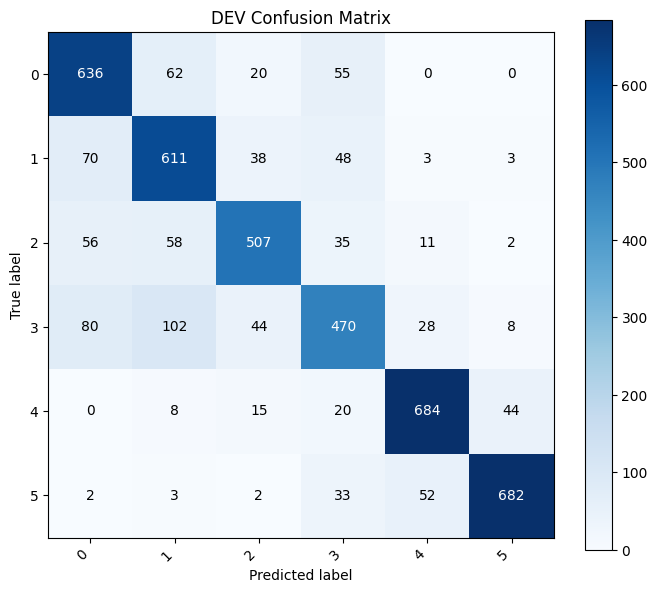


=== TEST ===
Accuracy: 0.7876
Macro-F1: 0.7853
QWK:      0.8824


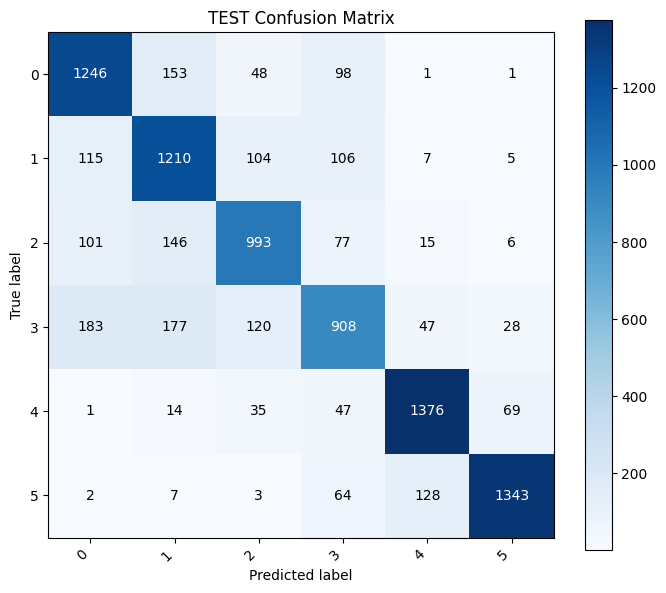


DEV QWK  = 0.8860
TEST QWK = 0.8824


In [165]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, cohen_kappa_score

def evaluate_with_cm(name, model, X, y, class_names=None, normalize=False):
    y_pred = model.predict(X)

    acc = accuracy_score(y, y_pred)
    mf1 = f1_score(y, y_pred, average="macro")
    qwk = cohen_kappa_score(y, y_pred, weights="quadratic")

    print(f"\n=== {name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro-F1: {mf1:.4f}")
    print(f"QWK:      {qwk:.4f}")

    cm = confusion_matrix(y, y_pred)
    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        cm = np.nan_to_num(cm)

    plt.figure(figsize=(7, 6))
    plt.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.title(f"{name} Confusion Matrix" + (" (Normalized)" if normalize else ""))
    plt.colorbar()

    if class_names is None:
        class_names = [str(i) for i in range(len(np.unique(y)))]

    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45, ha="right")
    plt.yticks(ticks, class_names)

    fmt = ".2f" if normalize else "d"
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, format(cm[i, j], fmt),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

    return qwk, y_pred

# Labels 0..5 (change to 1..6 if you prefer)
class_names = [str(i) for i in range(6)]

qwk_dev, _  = evaluate_with_cm("DEV", svm_model, X_dev, y_dev, class_names=class_names, normalize=False)
qwk_test, _ = evaluate_with_cm("TEST", svm_model, X_test, y_test, class_names=class_names, normalize=False)

print(f"\nDEV QWK  = {qwk_dev:.4f}")
print(f"TEST QWK = {qwk_test:.4f}")

In [167]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, cohen_kappa_score

def evaluate_with_cm(name, model, X, y, class_names=None, normalize=True):
    y_pred = model.predict(X)

    acc = accuracy_score(y, y_pred)
    mf1 = f1_score(y, y_pred, average="macro")
    qwk = cohen_kappa_score(y, y_pred, weights="quadratic")

    print(f"\n=== {name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro-F1: {mf1:.4f}")
    print(f"QWK:      {qwk:.4f}")

    cm = confusion_matrix(y, y_pred)

    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        cm = np.nan_to_num(cm)

    plt.figure(figsize=(7, 6))
    plt.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.title(f"{name} Normalized Confusion Matrix")
    plt.colorbar()

    if class_names is None:
        class_names = [str(i) for i in range(len(np.unique(y)))]

    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45, ha="right")
    plt.yticks(ticks, class_names)

    # Show percentages inside cells
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]
            plt.text(
                j, i,
                f"{value:.2f}",  # shows proportion (0.85)
                ha="center",
                va="center",
                color="white" if value > 0.5 else "black"
            )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

    return qwk, y_pred


Evaluation: DEV
Accuracy  : 0.7992
Macro-F1  : 0.7975
QWK       : 0.8860


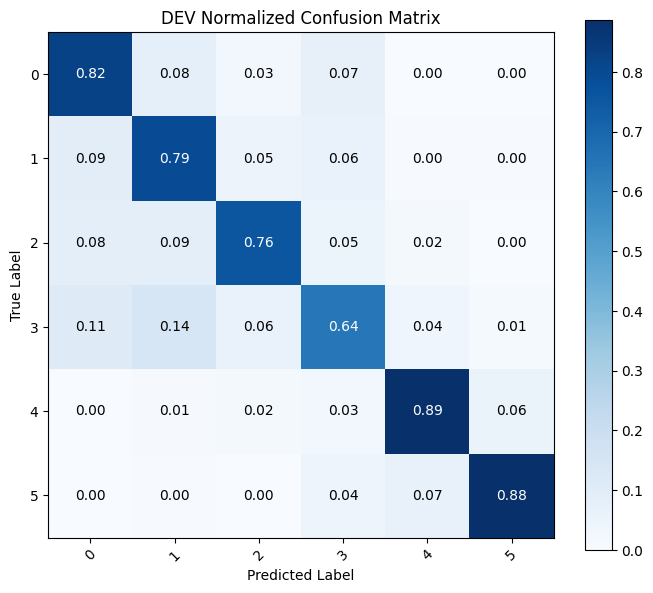


Evaluation: TEST
Accuracy  : 0.7876
Macro-F1  : 0.7853
QWK       : 0.8824


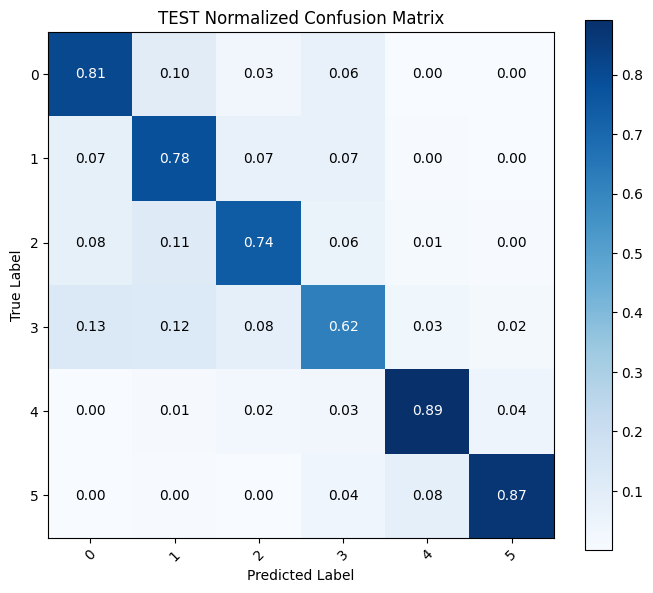


DEV QWK  = 0.8860
TEST QWK = 0.8824


In [169]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, cohen_kappa_score

def evaluate_with_cm(name, model, X, y, class_names=None):
    y_pred = model.predict(X)

    acc = accuracy_score(y, y_pred)
    mf1 = f1_score(y, y_pred, average="macro")
    qwk = cohen_kappa_score(y, y_pred, weights="quadratic")

    print("\n==============================")
    print(f"Evaluation: {name}")
    print("==============================")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Macro-F1  : {mf1:.4f}")
    print(f"QWK       : {qwk:.4f}")

    cm = confusion_matrix(y, y_pred).astype(float)
    cm = cm / cm.sum(axis=1, keepdims=True)  # row-normalized
    cm = np.nan_to_num(cm)

    plt.figure(figsize=(7, 6))
    plt.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.title(f"{name} Normalized Confusion Matrix")
    plt.colorbar()

    if class_names is None:
        class_names = [str(i) for i in range(len(np.unique(y)))]

    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45)
    plt.yticks(ticks, class_names)

    # Annotate with decimals (e.g., 0.82)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]
            plt.text(
                j, i,
                f"{value:.2f}",   # <-- decimals like 0.82
                ha="center",
                va="center",
                color="white" if value > 0.5 else "black"
            )

    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()

    return qwk


# Run
class_names = [str(i) for i in range(6)]
qwk_dev  = evaluate_with_cm("DEV", svm_model, X_dev, y_dev, class_names)
qwk_test = evaluate_with_cm("TEST", svm_model, X_test, y_test, class_names)

print(f"\nDEV QWK  = {qwk_dev:.4f}")
print(f"TEST QWK = {qwk_test:.4f}")

In [170]:
import numpy as np
import pandas as pd

# Load your hybrid data
train_hybrid = pd.read_pickle("/kaggle/working/train_hybrid.pkl")
dev_hybrid   = pd.read_pickle("/kaggle/working/dev_hybrid.pkl")
test_hybrid  = pd.read_pickle("/kaggle/working/test_hybrid.pkl")

TARGET_COL = "labels"

DROP_COLS = {
    "row_id", TARGET_COL,
    "Level", "text", "Word", "D3Tok", "Lex", "D3Lex"
}

def make_xy(df):
    y = df[TARGET_COL].astype(int).values
    X = df.drop(columns=[c for c in df.columns if c in DROP_COLS], errors="ignore")
    X = X.apply(pd.to_numeric, errors="coerce").fillna(0.0)
    return X.values.astype(np.float32), y.astype(np.int64), list(X.columns)

X_train, y_train, feat_names = make_xy(train_hybrid)
X_dev,   y_dev,   _          = make_xy(dev_hybrid)
X_test,  y_test,  _          = make_xy(test_hybrid)

print("X_train:", X_train.shape, "num_features:", X_train.shape[1])

X_train: (31441, 36) num_features: 36


In [171]:
import numpy as np
import pandas as pd

# Load your hybrid data
train_hybrid = pd.read_pickle("/kaggle/working/train_hybrid.pkl")
dev_hybrid   = pd.read_pickle("/kaggle/working/dev_hybrid.pkl")
test_hybrid  = pd.read_pickle("/kaggle/working/test_hybrid.pkl")

TARGET_COL = "labels"

DROP_COLS = {
    "row_id", TARGET_COL,
    "Level", "text", "Word", "D3Tok", "Lex", "D3Lex"
}

def make_xy(df):
    y = df[TARGET_COL].astype(int).values
    X = df.drop(columns=[c for c in df.columns if c in DROP_COLS], errors="ignore")
    X = X.apply(pd.to_numeric, errors="coerce").fillna(0.0)
    return X.values.astype(np.float32), y.astype(np.int64), list(X.columns)

X_train, y_train, feat_names = make_xy(train_hybrid)
X_dev,   y_dev,   _          = make_xy(dev_hybrid)
X_test,  y_test,  _          = make_xy(test_hybrid)

print("X_train:", X_train.shape, "num_features:", X_train.shape[1])

X_train: (31441, 36) num_features: 36


In [173]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"

# Treat feature vector as a sequence: (batch, seq_len=num_features, input_size=1)
def to_seq(X):
    return X.reshape(X.shape[0], X.shape[1], 1)

train_ds = TensorDataset(torch.tensor(to_seq(X_train)), torch.tensor(y_train))
dev_ds   = TensorDataset(torch.tensor(to_seq(X_dev)),   torch.tensor(y_dev))
test_ds  = TensorDataset(torch.tensor(to_seq(X_test)),  torch.tensor(y_test))

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
dev_loader   = DataLoader(dev_ds, batch_size=512, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=512, shuffle=False)

class BiLSTMTabular(nn.Module):
    def __init__(self, hidden=64, num_layers=1, num_classes=6, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden * 2, num_classes)

    def forward(self, x):
        # x: (B, seq_len, 1)
        out, (h_n, c_n) = self.lstm(x)
        # last layer hidden: h_n shape (num_layers*2, B, hidden)
        h_fwd = h_n[-2]  # forward
        h_bwd = h_n[-1]  # backward
        h = torch.cat([h_fwd, h_bwd], dim=1)  # (B, 2*hidden)
        h = self.dropout(h)
        logits = self.fc(h)
        return logits

model = BiLSTMTabular(hidden=64, num_layers=1, num_classes=6, dropout=0.2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-2)

print(model)

BiLSTMTabular(
  (lstm): LSTM(1, 64, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=128, out_features=6, bias=True)
)


In [176]:
import torch
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score

def predict_all(model, loader, device):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            pred = logits.argmax(dim=1).cpu().numpy()
            ys.append(yb.numpy())
            ps.append(pred)
    y_true = np.concatenate(ys)
    y_pred = np.concatenate(ps)
    return y_true, y_pred

def ordinal_hard_loss(logits, labels, alpha=0.4, tau=2.0):
    """
    logits: (B, K)
    labels: (B,) int64 in [0..K-1]
    alpha: weight for ordinal KL loss
    tau: controls how sharp the ordinal distance distribution is (bigger = smoother)
    """
    # probs
    probs = torch.softmax(logits, dim=-1)

    # true class probs
    true_probs = probs.gather(1, labels.unsqueeze(1)).squeeze(1)  # (B,)

    # hard example weighting (like yours)
    difficulty_weight = 1.0 - true_probs.detach()
    difficulty_weight = difficulty_weight + 0.5
    difficulty_weight = difficulty_weight / difficulty_weight.mean()

    # CE per-sample (no reduction)
    ce_loss = F.cross_entropy(logits, labels, reduction="none")  # (B,)
    weighted_ce = ce_loss * difficulty_weight

    # ordinal distance penalty distribution
    K = logits.size(-1)
    indices = torch.arange(K, device=logits.device).float().unsqueeze(0)  # (1,K)
    labels_float = labels.float().unsqueeze(1)                              # (B,1)
    dist = torch.abs(indices - labels_float)                                # (B,K)

    distance_penalty = torch.exp(-dist / tau)                               # (B,K)
    distance_penalty = distance_penalty / distance_penalty.sum(dim=1, keepdim=True)

    # KL( target || predicted ) or KL(pred || target)?
    # Your code used: kl_div(log_probs, distance_penalty)
    log_probs = F.log_softmax(logits, dim=-1)
    ordinal_kl = F.kl_div(log_probs, distance_penalty, reduction="none").sum(dim=1)  # (B,)

    final_loss = (weighted_ce + alpha * ordinal_kl).mean()
    return final_loss

# ---- TRAIN ----
EPOCHS = 50
ALPHA = 0.4   # ordinal loss weight (same as your comment)
TAU   = 2.0   # distance smoothing (same as exp(-dist/2.0))

best_dev_qwk = -1.0
best_state = None

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)

        loss = ordinal_hard_loss(logits, yb, alpha=ALPHA, tau=TAU)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    # ---- DEV eval ----
    y_true, y_pred = predict_all(model, dev_loader, device)
    dev_acc = accuracy_score(y_true, y_pred)
    dev_f1  = f1_score(y_true, y_pred, average="macro")
    dev_qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")

    avg_loss = total_loss / max(len(train_loader), 1)
    print(f"Epoch {epoch:02d}/{EPOCHS} | loss {avg_loss:.4f} | DEV acc {dev_acc:.4f} | DEV mf1 {dev_f1:.4f} | DEV QWK {dev_qwk:.4f}")

    if dev_qwk > best_dev_qwk:
        best_dev_qwk = dev_qwk
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

# Load best
if best_state is not None:
    model.load_state_dict(best_state)

print("✅ Best DEV QWK:", best_dev_qwk)

Epoch 01/50 | loss 0.5836 | DEV acc 0.7952 | DEV mf1 0.7937 | DEV QWK 0.8895
Epoch 02/50 | loss 0.4806 | DEV acc 0.8003 | DEV mf1 0.7984 | DEV QWK 0.8888
Epoch 03/50 | loss 0.4738 | DEV acc 0.8023 | DEV mf1 0.8007 | DEV QWK 0.8888
Epoch 04/50 | loss 0.4703 | DEV acc 0.8023 | DEV mf1 0.8007 | DEV QWK 0.8887
Epoch 05/50 | loss 0.4687 | DEV acc 0.8021 | DEV mf1 0.8005 | DEV QWK 0.8883
Epoch 06/50 | loss 0.4668 | DEV acc 0.8010 | DEV mf1 0.7992 | DEV QWK 0.8875
Epoch 07/50 | loss 0.4671 | DEV acc 0.8016 | DEV mf1 0.7998 | DEV QWK 0.8872
Epoch 08/50 | loss 0.4653 | DEV acc 0.8014 | DEV mf1 0.7997 | DEV QWK 0.8882
Epoch 09/50 | loss 0.4649 | DEV acc 0.8021 | DEV mf1 0.8003 | DEV QWK 0.8887
Epoch 10/50 | loss 0.4644 | DEV acc 0.8025 | DEV mf1 0.8009 | DEV QWK 0.8886
Epoch 11/50 | loss 0.4635 | DEV acc 0.8019 | DEV mf1 0.8001 | DEV QWK 0.8877
Epoch 12/50 | loss 0.4637 | DEV acc 0.8019 | DEV mf1 0.8001 | DEV QWK 0.8886
Epoch 13/50 | loss 0.4628 | DEV acc 0.8014 | DEV mf1 0.7997 | DEV QWK 0.8882


=== TEST ===
Accuracy: 0.7896
Macro-F1: 0.7876
QWK:      0.8850


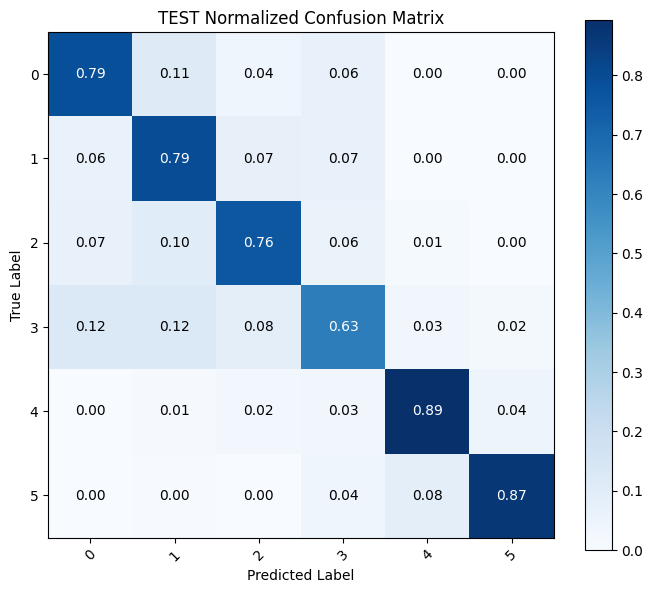

In [179]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, cohen_kappa_score
import numpy as np

y_true, y_pred = predict_all(model, test_loader, device)

test_acc = accuracy_score(y_true, y_pred)
test_f1  = f1_score(y_true, y_pred, average="macro")
test_qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")

print("\n=== TEST ===")
print(f"Accuracy: {test_acc:.4f}")
print(f"Macro-F1: {test_f1:.4f}")
print(f"QWK:      {test_qwk:.4f}")

cm = confusion_matrix(y_true, y_pred).astype(float)
cm = cm / cm.sum(axis=1, keepdims=True)
cm = np.nan_to_num(cm)

plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap="Blues", interpolation="nearest")
plt.title("TEST Normalized Confusion Matrix")
plt.colorbar()

ticks = np.arange(6)
plt.xticks(ticks, [str(i) for i in range(6)], rotation=45)
plt.yticks(ticks, [str(i) for i in range(6)])

for i in range(6):
    for j in range(6):
        v = cm[i, j]
        plt.text(j, i, f"{v:.2f}", ha="center", va="center",
                 color="white" if v > 0.5 else "black")

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()